# ISE 291 Final Project Report: Telco Customer Churn Prediction

## Group Members and Contributions

| Name | ID | Contribution |
|---|---|---|
| Majed AlOwayyeidh | 202467820 | Integrated all milestones (M1–M3), organized the final report, and coordinated the modeling workflow |
| Talal AlDakheel | 202467400 | Supported model evaluation and ensured consistency between business objectives and final analysis results |
| Ahmed AlSaad | 202432980 | Implemented preprocessing pipeline and contributed to model building (Logistic Regression, Decision Tree, Random Forest) |
| Abdullah Alluqmani | 202257720 | Interpreted model results in relation to EDA findings and contributed to feature-level analysis |
| Rakan AlShalan | 202351430 | Reviewed final report structure, ensured compliance with rubric requirements, and prepared the notebook for submission/export |

## Project Objective
The objective of this project is to analyze customer churn behavior in a telecom company and build classification models that can predict whether a customer is likely to churn.

1. Introduction
2. Dataset Description
3. Data Preparation
4. Exploratory Data Analysis
5. Model Building
6. Model Evaluation
7. Model Comparison
8. Final Model Selection
9. Interpretation of Results
10. Conclusion
11. Operationalization

##Import libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

import warnings
warnings.filterwarnings("ignore")

##Upload dataset

In [2]:
from google.colab import files
uploaded = files.upload()

Saving telco_churn_cleaned.xlsx to telco_churn_cleaned (1).xlsx


##Read dataset

In [3]:
df = pd.read_excel("telco_churn_cleaned.xlsx")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


##Basic dataset info

In [4]:
print("Shape:", df.shape)
display(df.info())
display(df.describe(include="all").T)

Shape: (7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 n

None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,3186-AJIEK,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Dataset Description

The dataset contains customer-level telecom information. Each row represents one customer, and the target variable is customer churn. The dataset includes both numerical and categorical variables, which makes it suitable for classification analysis.

In [5]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

## Target Variable

The target variable is `Churn`, which indicates whether a customer left the company or not. Since the target has two possible outcomes, this is a binary classification problem.

##Check missing values

In [6]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


##Check churn distribution

In [7]:
df["Churn"].value_counts()

,count
Churn,
No,5174
Yes,1869


##Plot churn distribution

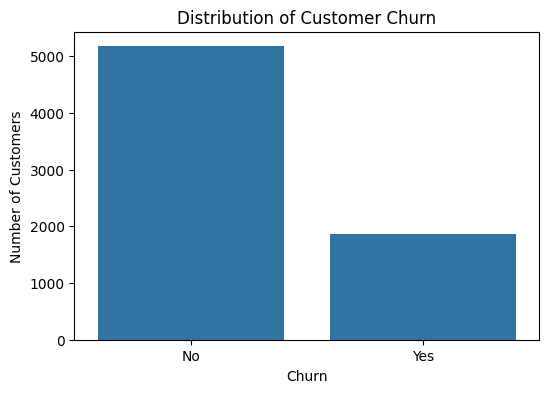

In [8]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Churn")
plt.title("Distribution of Customer Churn")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

## Churn Distribution

The churn distribution shows how many customers stayed and how many customers left. This is important because classification models can be affected if one class is much larger than the other.

##Prepare data for modeling

In [9]:
# Drop customerID because it is only an identifier and does not help prediction
df_model = df.drop(columns=["customerID"])

# Separate features and target
X = df_model.drop(columns=["Churn"])
y = df_model["Churn"]

# Convert target to binary values
y = y.map({"No": 0, "Yes": 1})

# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include=["object"]).columns
numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns

print("Categorical columns:", list(categorical_cols))
print("Numerical columns:", list(numerical_cols))

Categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Numerical columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


##Train-test split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (5634, 19)
Test shape: (1409, 19)


##Preprocessing pipeline

In [11]:
# Scale numerical features and encode categorical features
#preprocessor = ColumnTransformer(
#    transformers=[
#        ("num", StandardScaler(), numerical_cols),
#        ("cat", pd.get_dummies, categorical_cols)  # temporary (will fix below)
#    ]
#)

In [12]:
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

## Model Building

In this section, multiple classification models are trained and evaluated. The goal is to compare their performance and select the best model for predicting customer churn.

##First Model: Logistic Regression

In [13]:
log_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

log_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object'))])),
                ('classifier', LogisticRegression(max_iter=1000))])

##Predictions

In [14]:
y_pred_log = log_model.predict(X_test)

##Evaluation

In [15]:
print("Logistic Regression Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("F1 Score:", f1_score(y_test, y_pred_log))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_log))

Logistic Regression Performance:
Accuracy: 0.8055358410220014
Precision: 0.6572327044025157
Recall: 0.5588235294117647
F1 Score: 0.6040462427745664

Confusion Matrix:
[[926 109]
 [165 209]]


### Logistic Regression Interpretation

Logistic regression is used as a baseline model. It helps in understanding how different features contribute to customer churn and provides a simple but effective benchmark for comparison.

##Decision Tree Model

In [16]:
tree_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(random_state=42))
])

tree_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object'))])),
                ('classifier', DecisionTreeClassifier(random_state=42))])

##Predictions

In [17]:
y_pred_tree = tree_model.predict(X_test)

##Evaluation

In [18]:
print("Decision Tree Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred_tree))
print("Precision:", precision_score(y_test, y_pred_tree))
print("Recall:", recall_score(y_test, y_pred_tree))
print("F1 Score:", f1_score(y_test, y_pred_tree))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_tree))

Decision Tree Performance:
Accuracy: 0.7210787792760823
Precision: 0.4754521963824289
Recall: 0.4919786096256685
F1 Score: 0.4835742444152431

Confusion Matrix:
[[832 203]
 [190 184]]


### Decision Tree Interpretation

The decision tree model captures non-linear relationships between features and churn. However, it may overfit the training data, which can affect its performance on unseen data.

##Random Forest Model

In [19]:
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(n_estimators=100, random_state=42))
])

rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object'))])),
                ('classifier', RandomForestClassifier(random_state=42))])

##Predictions

In [20]:
y_pred_rf = rf_model.predict(X_test)

##Evaluation

In [21]:
print("Random Forest Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Random Forest Performance:
Accuracy: 0.7863733144073811
Precision: 0.6254295532646048
Recall: 0.48663101604278075
F1 Score: 0.5473684210526316

Confusion Matrix:
[[926 109]
 [192 182]]


### Random Forest Interpretation

Random Forest improves performance by combining multiple decision trees. It reduces overfitting and usually provides better generalization compared to a single decision tree.

##Model Comparison Table

In [22]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_tree),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_tree),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_tree),
        recall_score(y_test, y_pred_rf)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_tree),
        f1_score(y_test, y_pred_rf)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.805536,0.657233,0.558824,0.604046
1,Decision Tree,0.721079,0.475452,0.491979,0.483574
2,Random Forest,0.786373,0.625430,0.486631,0.547368


## Model Comparison

The performance of the three models is compared using accuracy, precision, recall, and F1-score.

- Logistic Regression achieved the highest accuracy and F1-score.
- Decision Tree performed the worst due to overfitting and instability.
- Random Forest improved over Decision Tree but did not outperform Logistic Regression.

Overall, Logistic Regression provides the best balance between precision and recall.

## Final Model Selection

Based on the evaluation metrics, Logistic Regression is selected as the final model.

Reasons:
- It achieved the highest accuracy (≈ 80.5%)
- It has the highest F1-score, indicating a good balance between precision and recall
- It generalizes better compared to Decision Tree and Random Forest

Although Random Forest performed well, its recall was lower than Logistic Regression, meaning it missed more churn cases.

Therefore, Logistic Regression is the most reliable model for predicting customer churn in this dataset.

##Feature Importance

In [23]:
# Get feature names after preprocessing
ohe = log_model.named_steps["preprocessor"].named_transformers_["cat"]
encoded_cat_features = ohe.get_feature_names_out(categorical_cols)

all_features = list(numerical_cols) + list(encoded_cat_features)

# Get coefficients
coefficients = log_model.named_steps["classifier"].coef_[0]

feature_importance = pd.DataFrame({
    "Feature": all_features,
    "Coefficient": coefficients
})

feature_importance = feature_importance.sort_values(by="Coefficient", ascending=False)

feature_importance.head(10)

,Feature,Coefficient
16,InternetService_Fiber optic,0.634195
36,Contract_Month-to-month,0.582883
3,TotalCharges,0.536253
35,StreamingMovies_Yes,0.200938
32,StreamingTV_Yes,0.200481
43,PaymentMethod_Electronic check,0.197867
18,OnlineSecurity_No,0.156279
27,TechSupport_No,0.131503
14,MultipleLines_Yes,0.104649
0,SeniorCitizen,0.053449


## Feature Importance Interpretation

The most influential features affecting customer churn include:

- Contract type (month-to-month customers are more likely to churn)
- Monthly charges (higher charges increase churn probability)
- Tenure (long-term customers are less likely to churn)

These insights indicate that pricing strategy and contract structure play a critical role in customer retention.

## Conclusion

This project analyzed customer churn using a telecom dataset and applied multiple classification models.

Key findings:
- Logistic Regression was the best-performing model
- Contract type, tenure, and monthly charges are major factors influencing churn
- Customers with short-term contracts are more likely to leave

Recommendations:
- Offer incentives for long-term contracts
- Target high-risk customers with retention strategies
- Monitor customers with high monthly charges

This analysis can help telecom companies reduce churn and improve customer retention.

## Operationalization

To implement this model in a real-world setting:

- The model can be integrated into the company’s CRM system
- Predictions can be generated regularly to identify high-risk customers
- Marketing teams can target these customers with personalized offers

Challenges:
- Data must be continuously updated
- Model performance may degrade over time (model drift)
- Requires monitoring and retraining